In [1]:
# [CELDA 1] IMPORTS
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Agregar la carpeta src al path para poder importar nuestra librería
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))

# Importar nuestra nueva herramienta
import analysis_statistics as au

# Configuración visual
plt.style.use('ggplot')
print("Entorno de análisis configurado.")

Entorno de análisis configurado.


In [2]:
# [CELDA 2] CARGA DE DATOS
file_path = '../data/processed/dataset_clean.csv'
df = au.cargar_y_preparar_datos(file_path)

print(f"Dataset cargado: {df.shape[0]} registros listos para análisis.")
df.head(3)

Dataset cargado: 9515 registros listos para análisis.


,order_id,customer_id,order_date,shipped_date,delivered_date,processing_days,delivery_days,promised_delivery_days,actual_delivery_days,delivery_delay_days,...,platform_name,is_peak_season,customer_delivery_rating,delivery_issue,shipping_cost_to_price_ratio,is_frequent_customer,is_loyal_customer,high_value_order,dias_reales,mes_anio
0,ECOMMX-2024-00000,CUST-25604,2025-03-21 14:47:03,2025-03-23 14:47:03,2025-03-28 14:47:03,2,5,6,5,-1,...,Liverpool,0,5,Ninguno,0.1059,0,1,1,5,2025-03
1,ECOMMX-2024-00001,CUST-93042,2025-12-22 02:25:19,2025-12-23 02:25:19,2025-12-25 02:25:19,1,2,2,2,0,...,Liverpool,1,5,Ninguno,0.0284,1,0,0,2,2025-12
2,ECOMMX-2024-00002,CUST-64249,2025-09-05 03:26:12,2025-09-08 03:26:12,2025-09-10 03:26:12,3,2,4,2,-2,...,Amazon México,0,5,Ninguno,0.8629,1,0,0,2,2025-09


In [3]:
# [CELDA 3] ESTADÍSTICA DESCRIPTIVA
print("--- RADIOGRAFÍA DE LOS TIEMPOS DE ENTREGA ---")
stats = au.generar_estadisticas_clave(df)
display(stats)

print("\nInterpetación: Fíjate en la 'varianza'. Si es muy alta, significa que nuestros procesos logísticos son inestables.")

--- RADIOGRAFÍA DE LOS TIEMPOS DE ENTREGA ---


,count,mean,std,min,25%,50%,75%,max,varianza,skewness
dias_reales,9515.0,5.890068,3.768571,1.0,3.0,5.0,7.0,25.0,14.202124,1.55498



Interpetación: Fíjate en la 'varianza'. Si es muy alta, significa que nuestros procesos logísticos son inestables.


--- RANKING DE EFICIENCIA LOGÍSTICA ---


,mean,std,count
shipping_carrier,,,
DHL,3.052260,1.366651,2124
UPS,3.902023,1.765273,939
FedEx,4.250859,1.587220,1746
Estafeta,6.170101,2.249502,2669
Redpack,7.194323,2.335955,458
Paquetexpress,7.994681,2.578184,188
Correos de México,12.371675,3.871204,1391


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categoria, y='dias_reales', order=orden, palette='viridis')


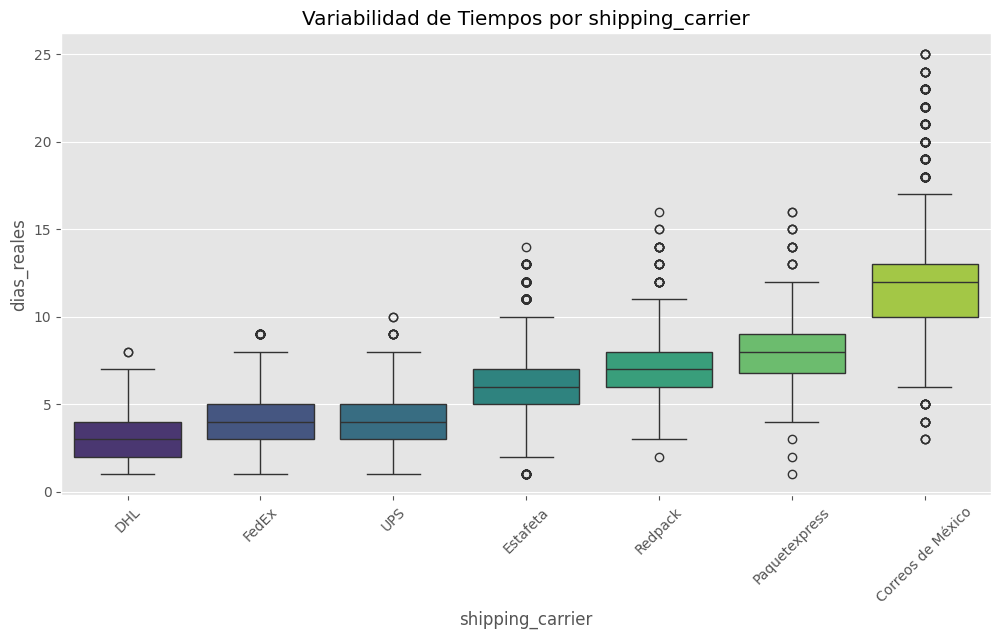

In [4]:
# [CELDA 4] ANÁLISIS POR TRANSPORTISTA
print("--- RANKING DE EFICIENCIA LOGÍSTICA ---")
ranking = au.analizar_factores(df, 'shipping_carrier')
display(ranking)

# Visualización
au.plot_comparativa_boxplots(df, 'shipping_carrier')
plt.show()

--- ¿QUÉ MUEVE LA AGUJA? (Correlaciones) ---
Rojo = Aumenta el tiempo (Malo) | Azul = Reduce el tiempo (Bueno)


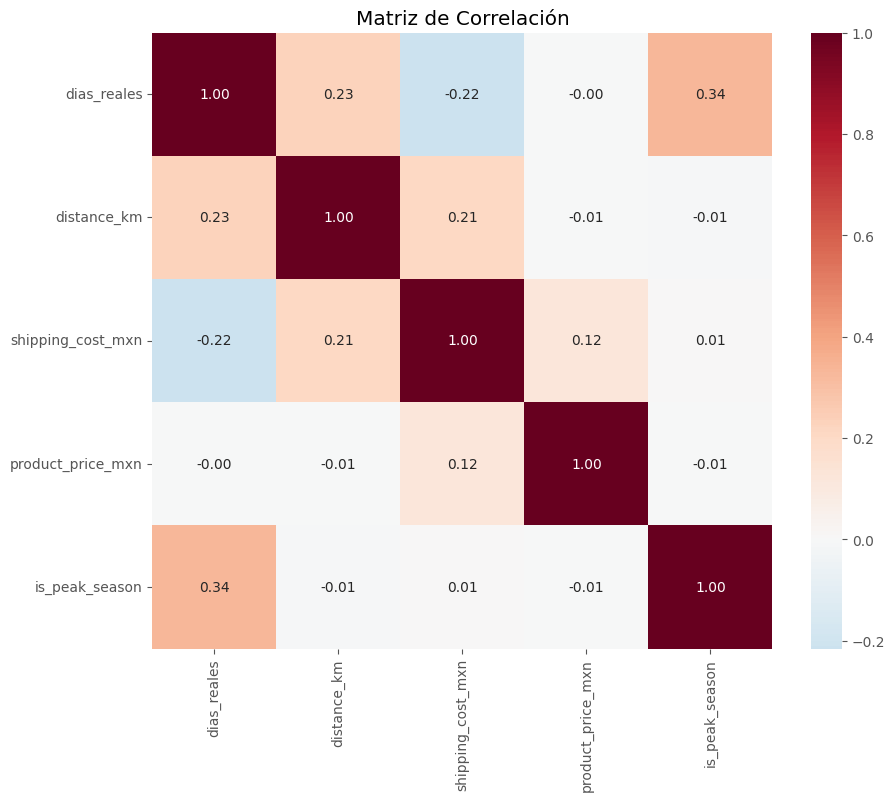

--- IMPACTO DE TEMPORADA ALTA ---


,mean,std,count
is_peak_season,,,
0,5.139994,3.029988,7036
1,8.018959,4.725649,2479


c:\Users\ayala\Documentos\ESCOM\TERCER SEMESTRE\PROGRAMACION PARA LA CIENCIA DE DATOS\E-COMMERCE PROYECT\ecommerce-delivery-analysis\src\analysis_statistics.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=categoria, y='dias_reales', order=orden, palette='viridis')


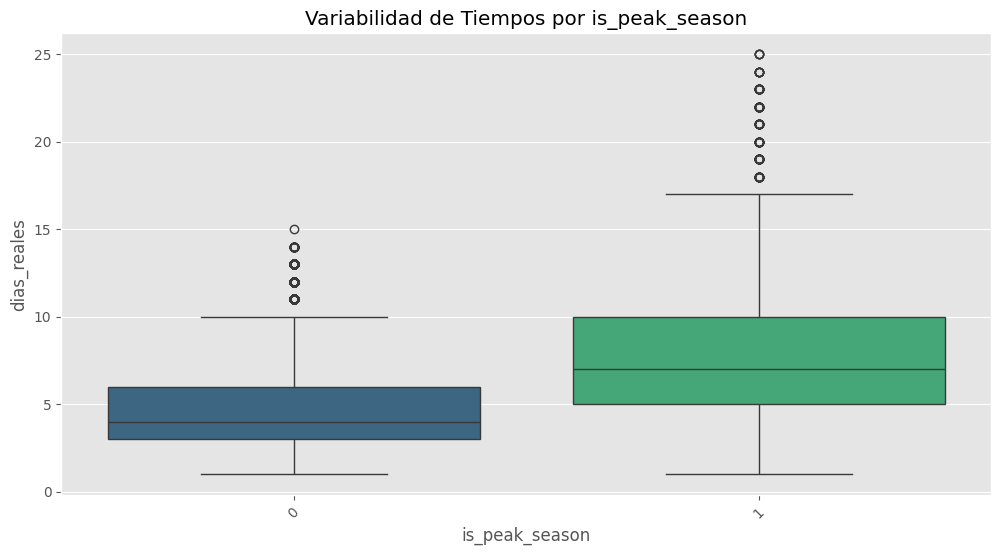

In [5]:
# [CELDA 5] FACTORES DE RETRASO (Correlaciones)
print("--- ¿QUÉ MUEVE LA AGUJA? (Correlaciones) ---")
print("Rojo = Aumenta el tiempo (Malo) | Azul = Reduce el tiempo (Bueno)")
au.plot_heatmap_correlaciones(df)
plt.show()

# [CELDA 6] ANÁLISIS DE TEMPORADA
print("--- IMPACTO DE TEMPORADA ALTA ---")
season_impact = au.analizar_factores(df, 'is_peak_season')
display(season_impact)

# Comparativa visual rápida
au.plot_comparativa_boxplots(df, 'is_peak_season')
plt.show()